In [1]:
import sys

print(sys.executable)

c:\Users\asus\OneDrive\Desktop\fake-news-detector1\project_env\Scripts\python.exe


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.13.0+cpu
CUDA: False


In [4]:
import sys
import os
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torchvision
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Python: c:\Users\asus\OneDrive\Desktop\fake-news-detector1\project_env\Scripts\python.exe
PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA available: False
Using CPU


In [5]:
DATASET_DIR = Path(
    r"C:\Users\asus\OneDrive\Desktop\fake-news-detector1\backend\datasets\image_dataset\archive (1)"
)

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

print("Dataset:", DATASET_DIR)

print("\nTrain exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

print("\nTrain folders:")
for folder in TRAIN_DIR.iterdir():
    print(folder.name)

print("\nTest folders:")
for folder in TEST_DIR.iterdir():
    print(folder.name)

Dataset: C:\Users\asus\OneDrive\Desktop\fake-news-detector1\backend\datasets\image_dataset\archive (1)

Train exists: True
Test exists: True

Train folders:
FAKE
REAL

Test folders:
FAKE
REAL


In [6]:
train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR)
)

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR)
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("\nTraining images:", len(train_dataset))
print("Test images:", len(test_dataset))

Classes: ['FAKE', 'REAL']
Class mapping: {'FAKE': 0, 'REAL': 1}

Training images: 83554
Test images: 20000


In [7]:
train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

print("TRAIN")
print("-" * 30)

for class_index, class_name in enumerate(train_dataset.classes):
    print(
        f"{class_name}: "
        f"{train_counts[class_index]}"
    )

print("\nTEST")
print("-" * 30)

for class_index, class_name in enumerate(test_dataset.classes):
    print(
        f"{class_name}: "
        f"{test_counts[class_index]}"
    )

TRAIN
------------------------------
FAKE: 33554
REAL: 50000

TEST
------------------------------
FAKE: 10000
REAL: 10000


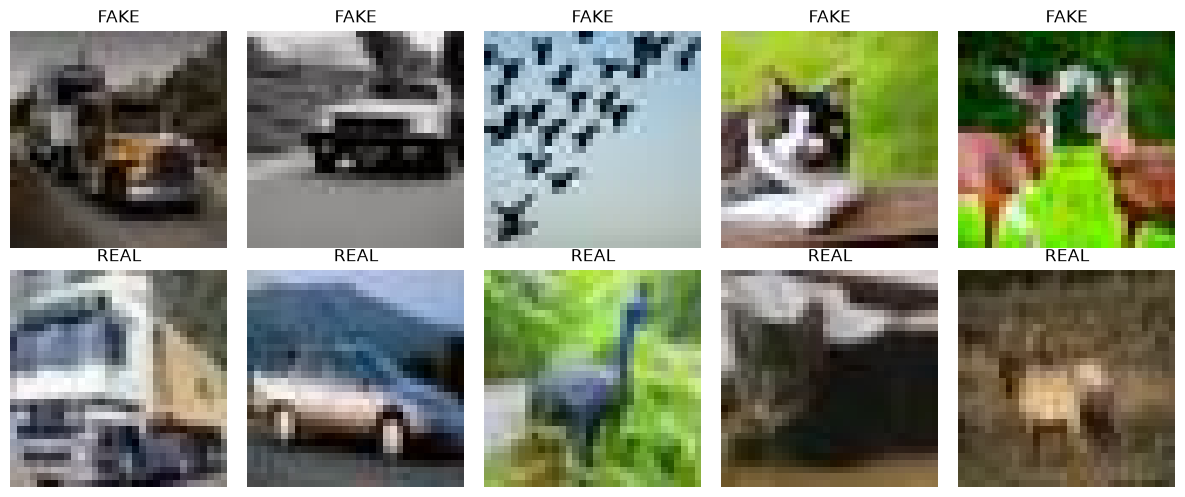

In [8]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for row, class_name in enumerate(["FAKE", "REAL"]):

    folder = TRAIN_DIR / class_name

    image_files = []

    for file in folder.iterdir():

        if file.is_file():
            image_files.append(file)

        if len(image_files) == 5:
            break

    for col, image_path in enumerate(image_files):

        image = Image.open(image_path)

        axes[row, col].imshow(image)

        axes[row, col].set_title(
            class_name
        )

        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [9]:
sample_fake = next(
    (TRAIN_DIR / "FAKE").iterdir()
)

sample_real = next(
    (TRAIN_DIR / "REAL").iterdir()
)

with Image.open(sample_fake) as img:

    print("FAKE image")
    print("Format:", img.format)
    print("Size:", img.size)
    print("Mode:", img.mode)

print()

with Image.open(sample_real) as img:

    print("REAL image")
    print("Format:", img.format)
    print("Size:", img.size)
    print("Mode:", img.mode)

FAKE image
Format: JPEG
Size: (32, 32)
Mode: RGB

REAL image
Format: JPEG
Size: (32, 32)
Mode: RGB


In [10]:
fake_count = train_counts[train_dataset.class_to_idx["FAKE"]]
real_count = train_counts[train_dataset.class_to_idx["REAL"]]

imbalance_ratio = fake_count / real_count

print("FAKE images:", fake_count)
print("REAL images:", real_count)

print(
    f"\nFAKE is approximately "
    f"{imbalance_ratio:.2f}x the REAL class."
)

FAKE images: 33554
REAL images: 50000

FAKE is approximately 0.67x the REAL class.


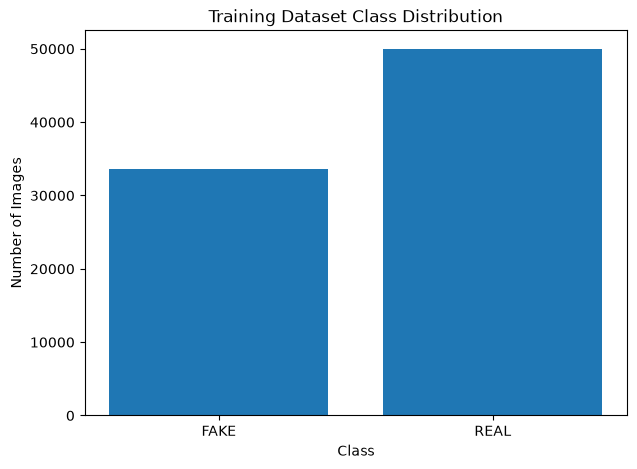

In [11]:
class_names = train_dataset.classes

counts = [
    train_counts[i]
    for i in range(len(class_names))
]

plt.figure(figsize=(7, 5))

plt.bar(
    class_names,
    counts
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [12]:
all_indices = np.arange(
    len(train_dataset)
)

all_labels = np.array(
    train_dataset.targets
)

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(validation_indices))

Training samples: 66843
Validation samples: 16711


In [14]:
train_split_labels = all_labels[
    train_indices
]

validation_split_labels = all_labels[
    validation_indices
]

print("TRAINING SPLIT")
print("-" * 30)

for class_index, class_name in enumerate(
    train_dataset.classes
):

    count = np.sum(
        train_split_labels == class_index
    )

    print(
        f"{class_name}: {count}"
    )

print("\nVALIDATION SPLIT")
print("-" * 30)

for class_index, class_name in enumerate(
    train_dataset.classes
):

    count = np.sum(
        validation_split_labels == class_index
    )

    print(
        f"{class_name}: {count}"
    )

TRAINING SPLIT
------------------------------
FAKE: 26843
REAL: 40000

VALIDATION SPLIT
------------------------------
FAKE: 6711
REAL: 10000


In [15]:
print("ImageFolder training dataset:", len(train_dataset))
print("ImageFolder test dataset:", len(test_dataset))

print("\nClasses:")
print(train_dataset.class_to_idx)

print("\nOriginal class counts:")
for class_idx, class_name in enumerate(train_dataset.classes):
    print(class_name, train_dataset.targets.count(class_idx))

ImageFolder training dataset: 83554
ImageFolder test dataset: 20000

Classes:
{'FAKE': 0, 'REAL': 1}

Original class counts:
FAKE 33554
REAL 50000


In [16]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

validation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [17]:
from torch.utils.data import Subset

train_full = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform
)

validation_full = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=validation_transform
)

train_data = Subset(
    train_full,
    train_indices
)

validation_data = Subset(
    validation_full,
    validation_indices
)

print("Training samples:", len(train_data))
print("Validation samples:", len(validation_data))

Training samples: 66843
Validation samples: 16711


In [18]:
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_data = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=test_transform
)

print("Test samples:", len(test_data))
print("Test classes:", test_data.classes)

Test samples: 20000
Test classes: ['FAKE', 'REAL']


In [19]:
image, label = train_data[0]

print("Tensor shape:", image.shape)
print("Label:", label)
print("Label name:", train_dataset.classes[label])

Tensor shape: torch.Size([3, 224, 224])
Label: 0
Label name: FAKE


In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created.")
print("Batch size:", BATCH_SIZE)

DataLoaders created.
Batch size: 32


In [21]:
import torch
import numpy as np

class_counts = np.array([
    train_counts[0],
    train_counts[1]
])

total_samples = class_counts.sum()
num_classes = len(class_counts)

class_weights = total_samples / (
    num_classes * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class counts:")
print("FAKE:", class_counts[0])
print("REAL:", class_counts[1])

print("\nClass weights:")
print("FAKE:", class_weights[0].item())
print("REAL:", class_weights[1].item())

Class counts:
FAKE: 33554
REAL: 50000

Class weights:
FAKE: 1.2450675964355469
REAL: 0.8355399966239929


In [22]:
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [23]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

weights = ResNet18_Weights.DEFAULT

model = resnet18(
    weights=weights
)

# Replace the original ImageNet classifier
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\asus/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:18<00:00, 2.50MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [24]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [25]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer:", optimizer.__class__.__name__)

Optimizer: AdamW


In [26]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 2])


In [27]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 2])


In [28]:
model.train()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

print("One training step completed!")
print("Loss:", loss.item())

One training step completed!
Loss: 0.7566894292831421


In [29]:
from torch.utils.data import Subset
import numpy as np

SMALL_TRAIN_SIZE_PER_CLASS = 2500

small_indices = []

for class_idx in [0, 1]:
    class_indices = np.where(
        all_labels == class_idx
    )[0]

    selected = np.random.default_rng(42).choice(
        class_indices,
        size=SMALL_TRAIN_SIZE_PER_CLASS,
        replace=False
    )

    small_indices.extend(selected)

small_indices = np.array(small_indices)

small_train_data = Subset(
    train_full,
    small_indices
)

small_train_loader = DataLoader(
    small_train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

print("Small training dataset:", len(small_train_data))

Small training dataset: 5000


In [30]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [31]:
loss, accuracy = train_one_epoch(
    model,
    small_train_loader,
    criterion,
    optimizer,
    device
)

print("Training loss:", loss)
print("Training accuracy:", accuracy)

Training loss: 0.27670249524116514
Training accuracy: 0.8738


In [32]:
def evaluate_model(model, loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return np.array(all_labels), np.array(all_predictions)


validation_labels, validation_predictions = evaluate_model(
    model,
    validation_loader,
    device
)

validation_accuracy = accuracy_score(
    validation_labels,
    validation_predictions
)

print(
    "Validation accuracy:",
    validation_accuracy
)

Validation accuracy: 0.8378313685596314


In [33]:
print(
    classification_report(
        validation_labels,
        validation_predictions,
        target_names=train_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

        FAKE     0.7168    0.9857    0.8300      6711
        REAL     0.9872    0.7386    0.8450     10000

    accuracy                         0.8378     16711
   macro avg     0.8520    0.8621    0.8375     16711
weighted avg     0.8786    0.8378    0.8390     16711



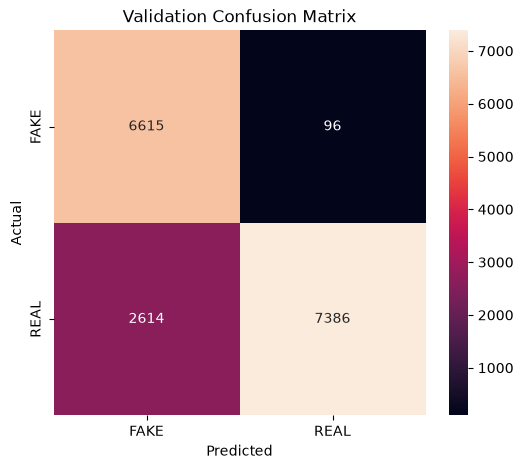

In [34]:
cm = confusion_matrix(
    validation_labels,
    validation_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

plt.show()